In [33]:
# Library Call #
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# File Reading #
rt_main = pd.read_csv("C:\\Users\\User\\Documents\\3MTT\\Kaggle dataset\\online_retail_II.csv")

Before moving forward, I would to create a copy, so that change made would not affect the main file

In [35]:
# Let the name of the copy be "rt" #
rt = rt_main.copy()

In [36]:
# Knowledge of Data #
rt.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [37]:
rt.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [38]:
rt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


# Data Cleaning #

In [39]:
rt.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

From the dataset description, 
it is discovered that the variables(Quantity and Price) contains negative values which may be perceive as errors but it is not, why? 
This is because negative values indicate refunds for unwanted or damaged goods

# Next we clean up "Customer ID"
The computer ses the customer IDs as int so we convert it to string,
but before change customer ID to string, 
we need to remove the Nan in the column as seen from the info section above

In [40]:
rt.dropna(subset=['Customer ID'], inplace = True)

Then we check if the Nan are actually dropped

In [41]:
print(rt['Customer ID'])

0          13085.0
1          13085.0
2          13085.0
3          13085.0
4          13085.0
            ...   
1067366    12680.0
1067367    12680.0
1067368    12680.0
1067369    12680.0
1067370    12680.0
Name: Customer ID, Length: 824364, dtype: float64


In [42]:
rt['Customer ID'].sample(10)

973938    14524.0
725169    16341.0
190994    14329.0
925193    14547.0
556854    16782.0
910105    17596.0
131083    16782.0
916700    17554.0
776235    13694.0
496034    14030.0
Name: Customer ID, dtype: float64

In [43]:
# Since the Customer ID is not needed for analysis and modelling, it is converted to string
# It is not removed or dropped just yet, because it will be needed for modelling later on

rt['Customer ID'] = rt['Customer ID'].astype(str)

In [44]:
# We select the numeric variables as the other variables are strings #
numeric = rt.select_dtypes(include = ["int", "float"])

In [45]:
print(numeric)

         Quantity  Price
0              12   6.95
1              12   6.75
2              12   6.75
3              48   2.10
4              24   1.25
...           ...    ...
1067366         6   2.10
1067367         4   4.15
1067368         4   4.15
1067369         3   4.95
1067370         1  18.00

[824364 rows x 2 columns]


In [46]:
# Check if it contains null values #
rt.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

# Data Cleaning Continues

In [47]:
# We first checkout the mean, median and mode
columns = ['Quantity', 'Price']
for col in columns:
    mean = rt[col].mean()
    mode = rt[col].mode()
    median = rt[col].median()
    print(f'\nMean of {col} = {mean}')
    print(f'Mode of {col} = {mode}')
    print(f'Median of {col} = {median}')
    


Mean of Quantity = 12.414574144431343
Mode of Quantity = 0    1
Name: Quantity, dtype: int64
Median of Quantity = 5.0

Mean of Price = 3.6767995788268304
Mode of Price = 0    1.25
Name: Price, dtype: float64
Median of Price = 1.95


# Finding out what rows of dataset of prices and quantity cotains value of zero, which can not be plausible without errors #

In [48]:
columns = ['Quantity', 'Price']
for col in columns:
    print(f'\nZero values rows of {col} are:', np.where(rt[col] == 0))


Zero values rows of Quantity are: (array([], dtype=int64),)

Zero values rows of Price are: (array([  3754,   4889,  12998,  14558,  14559,  24546,  29570,  33605,
        34802,  39665,  63878,  63968,  82314, 112480, 112481, 126121,
       180938, 187631, 193807, 216936, 233239, 258429, 284923, 289479,
       313268, 320207, 352938, 364355, 378036, 378037, 409743, 424546,
       440605, 443580, 447415, 447417, 452994, 472813, 505437, 512735,
       517479, 527502, 549399, 558051, 617033, 619607, 622161, 631666,
       646893, 646894, 646895, 646896, 679978, 683124, 697920, 711112,
       732025, 744997, 745164, 745526, 747428, 753640, 754272, 754273,
       759648, 759649, 778388, 778766, 779842, 784382, 796428],
      dtype=int64),)


Since there are zeros in only the column of "Price", We ought to take of it

In [49]:
# First, we find the number of rows that contains zeros #
(rt['Price'] == 0).sum()

71

In [50]:
# Location and Replacing the Zero values with the median #
rt.loc[rt['Price'] == 0, 'Price'] = rt['Price'].median()

In [51]:
# We check the replacement #
np.where(rt['Price'] == rt['Price'].median())

(array([    79,    143,    159, ..., 824348, 824355, 824356], dtype=int64),)

In [52]:
rt.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


Let's take a look out for duplicates

In [53]:
rt.duplicated().sum()

26480

In [54]:
rt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  object 
 7   Country      824364 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 56.6+ MB


In [55]:
# Dropping duplicates #
rt = rt.drop_duplicates()

In [56]:
# Checking if they were actually removed #
rt.duplicated().sum()

0

Dealing with the outliers

Diffeerentiating between the outliers(really small and the really big values) using Quantile 

In [57]:
columns = ['Quantity', 'Price']
for col in columns:
    rt[col] = rt[col].astype(float)
    
    Q1 = rt[col].quantile(0.25)
    Q3 = rt[col].quantile(0.75)
    
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = rt[(rt[col] < lower_bound) |
                  (rt[col] > upper_bound)]
    
    print(f"\n \n {rt[col]}: {len(outliers)} outliers in the {col} column")
    
   # Now that we know the number of outliers
    # The outliers are left untouched because a customer can buy as many things as he/she wants to#


 
 0          12.0
1          12.0
2          12.0
3          48.0
4          24.0
           ... 
1067366     6.0
1067367     4.0
1067368     4.0
1067369     3.0
1067370     1.0
Name: Quantity, Length: 797884, dtype: float64: 53167 outliers in the Quantity column

 
 0           6.95
1           6.75
2           6.75
3           2.10
4           1.25
           ...  
1067366     2.10
1067367     4.15
1067368     4.15
1067369     4.95
1067370    18.00
Name: Price, Length: 797884, dtype: float64: 69161 outliers in the Price column


# Exploratory Data Analysis(EDA)

Now, we that we are done with missing values, impossible zero values, wrong datatypes and outliers,
We can now consider Exploratory Data Analysis even though some has been done during data cleaning

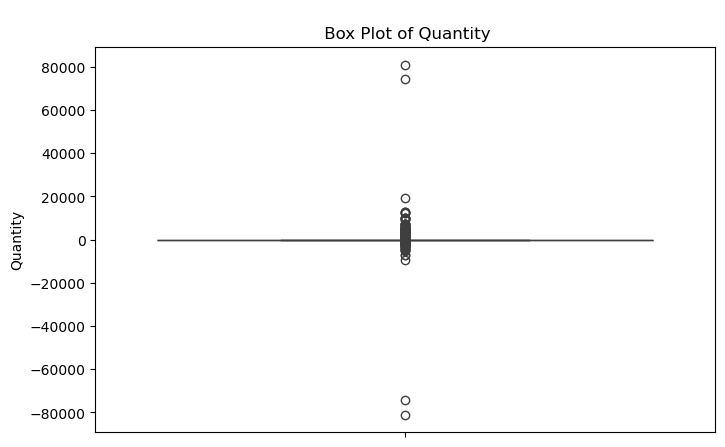

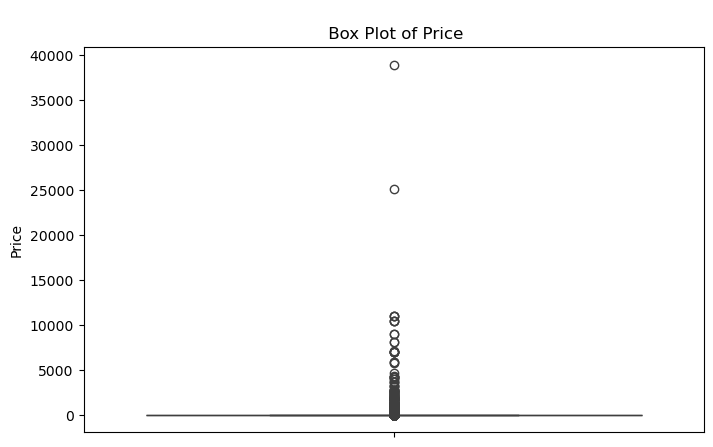

In [58]:
# Visualization by Box plot #
columns = ['Quantity', 'Price']
for col in columns:
    plt.figure(figsize = (8, 5))
    sns.boxplot(rt[col])
    plt.title(f'\n Box Plot of {col}')

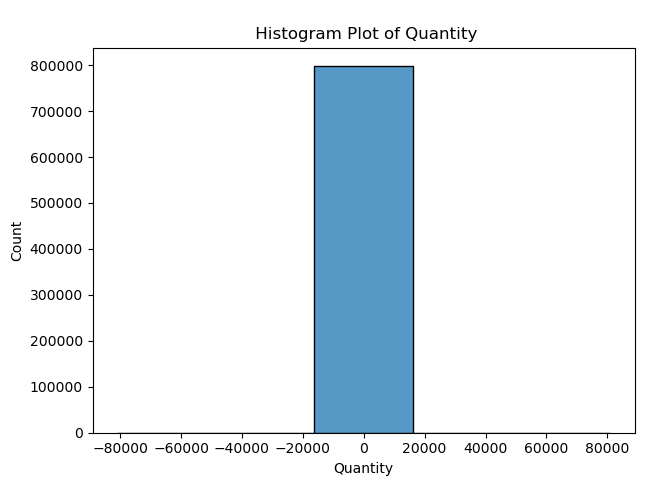

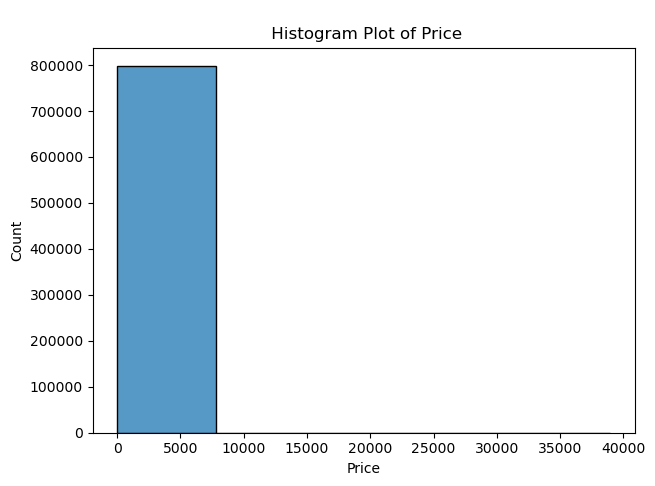

In [59]:
# Visualization by Histogram #
columns = ['Quantity', 'Price']
for col in columns:
    plt.figure(figsize= (7, 5))
    sns.histplot(rt[col], bins = 5)
    plt.title(f'\n Histogram Plot of {col}')
    plt.show()

In [60]:
rt['Price'].head()

0    6.95
1    6.75
2    6.75
3    2.10
4    1.25
Name: Price, dtype: float64

In [61]:
rt['Quantity'].head()

0    12.0
1    12.0
2    12.0
3    48.0
4    24.0
Name: Quantity, dtype: float64

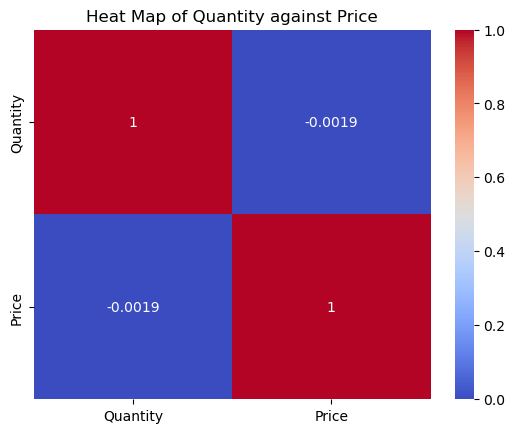

In [62]:
# Correlation heatmap
sns.heatmap(rt.select_dtypes(include = ['float64']).corr(), annot = True, cmap = 'coolwarm')
plt.title("Heat Map of Quantity against Price")
plt.show()

The quanity and price have a negative correlation of -0.0019 as seen above, meaning that as quantity increases price decreases, but the correlation coefficient is closer to zero, and consider to be too low.

let us take a look at the scatter plot

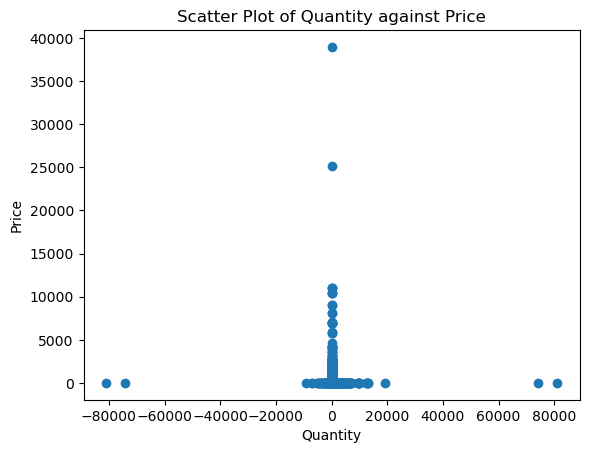

In [64]:
plt.scatter(rt['Quantity'], rt['Price'])
plt.title('Scatter Plot of Quantity against Price')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.show()

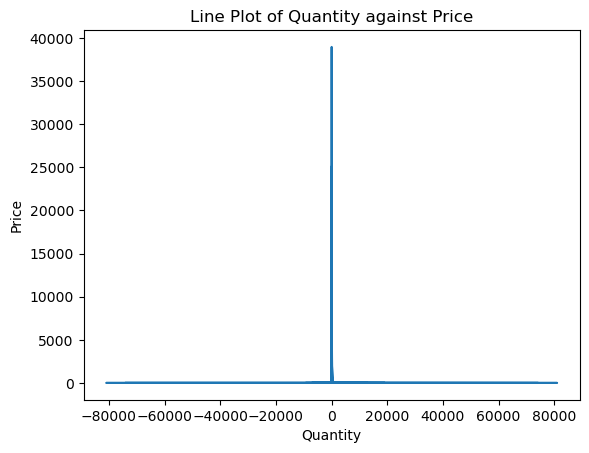

In [65]:
plt.plot(rt['Quantity'], rt['Price'])
plt.title('Line Plot of Quantity against Price')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.show()

In [66]:
rt['Quantity'].sample(30)

612661      4.0
660126      6.0
360117      6.0
712553      1.0
964266     12.0
955209      1.0
504987      6.0
122682     12.0
445633      8.0
323003      1.0
444434     10.0
408936      3.0
1333        1.0
157347      8.0
338172     12.0
1067080     8.0
587382      4.0
285136      3.0
107498     48.0
377541      1.0
721775     12.0
812864     20.0
357487      8.0
266360      4.0
663725      4.0
945263      1.0
974331      3.0
729159     12.0
1059240    16.0
986774     12.0
Name: Quantity, dtype: float64

From the charts(scatter and line plots), you will see that when the quantity is close to zero, the prices are higher, which indicates that customers who purchase goods in smaller quantities, buy goods that are more expensive, so they tend to buy them in smaller quantities

# Preprocessing(Encoding) #
Now we encode the variable/column, "Country" to aid the processing by the computer

In [67]:
# First we call the Label Encoder from the scikit library #
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

# Specify the columns to be encoded #
columns = ['Country']
for col in columns:
    rt[col] = encoder.fit_transform(rt[col])

In [68]:
rt['Country'].sample(10)

103014    38
668682     8
602167    38
199476    38
414347    14
946910    38
476804    38
138846    38
413179    38
819441    38
Name: Country, dtype: int32

One-hot Encoder can be used but I did not use it because of the multiple countries are involved and because the model to be created is a cluster

# Feature Engineering 👇👇👇👇

# Time to create some variables/columns that will be used to train the model(Feature Engineering) #
# We are going for:
Total Amount and,
Customer_Frequency


In [69]:
# Customer Fequency #
frequency= rt['Customer ID'].value_counts()
rt['Customer Frequency'] = rt['Customer ID'].map(frequency)

In [70]:
print(rt['Customer Frequency'])

0          92
1          92
2          92
3          92
4          92
           ..
1067366    53
1067367    53
1067368    53
1067369    53
1067370    53
Name: Customer Frequency, Length: 797884, dtype: int64


In [71]:
# We verify it's addition of customer frequency by checking the variables/columns
rt.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer Frequency
1008229,577483,85071D,CHARLIE+LOLA MY ROOM DOOR SIGN,1.0,2011-11-20 11:50:00,0.39,14502.0,38,615
3111,489654,20886,BOX OF 9 PEBBLE CANDLES,3.0,2009-12-01 17:19:00,1.95,15750.0,38,642
522048,537837,22507,MEMO BOARD RETROSPOT DESIGN,4.0,2010-12-08 14:59:00,4.95,13077.0,38,337
341791,522760,21494,ROTATING LEAVES T-LIGHT HOLDER,2.0,2010-09-16 13:48:00,1.25,15962.0,38,55
938094,572294,84988,SET OF 72 PINK HEART PAPER DOILIES,5.0,2011-10-23 13:10:00,1.45,13471.0,38,254
766810,558198,17038,PORCELAIN BUDAH INCENSE HOLDER,1.0,2011-06-27 12:49:00,0.10,14104.0,38,135
304364,519115,84978,HANGING HEART JAR T-LIGHT HOLDER,1.0,2010-08-13 11:59:00,1.25,17639.0,38,79
965744,574529,21090,SET/6 COLLAGE PAPER PLATES,6.0,2011-11-04 14:06:00,0.39,17233.0,38,58
317484,520344,21755,LOVE BUILDING BLOCK WORD,1.0,2010-08-25 13:05:00,5.95,13680.0,38,667
942699,572652,23319,BOX OF 6 MINI 50'S CRACKERS,6.0,2011-10-25 12:11:00,2.49,15805.0,38,556


In [72]:
# Total Amount #
# The amount of money spent by summing the unit purchase multplied by the price
rt['Total Amount'] = rt['Quantity'] * rt['Price']

In [73]:
# We verify it's addition by checking the variables/columns
rt.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer Frequency,Total Amount
804463,561222,22492,MINI PAINT SET VINTAGE,36.0,2011-07-26 09:27:00,0.65,13588.0,38,180,23.40
234132,512071,21916,SET 12 RETRO WHITE CHALK STICKS,3.0,2010-06-13 11:36:00,0.42,13736.0,38,565,1.26
942691,572652,23312,VINTAGE CHRISTMAS GIFT SACK,4.0,2011-10-25 12:11:00,4.15,15805.0,38,556,16.60
181434,506579,84997C,BLUE 3 PIECE MINI DOTS CUTLERY SET,18.0,2010-04-30 14:01:00,3.75,12374.0,1,83,67.50
282681,516913,22654,DELUXE SEWING KIT,2.0,2010-07-25 11:07:00,5.95,13875.0,38,270,11.90


# Rescaling #

Rescaling is required to prevent K-Means from making use of the differences between values of different columns to create the model,
so every column used is rescaled from 0 to 1

In [74]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

columns = ['Quantity', 'Price', 'Customer Frequency', 'Total Amount', 'Country']
for col in columns:
    rt[col] = scaler.fit_transform(rt[[col]])

# Model 

⚠ We first identify the columns present ⚠

In [75]:
rt.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Customer Frequency',
       'Total Amount'],
      dtype='object')

⚠ Then we drop the non-numerical columns ⚠

In [76]:
rt = rt.drop(['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Customer ID'], axis = 1)

⚠ We then check if the columns were actually dropped ⚠

In [77]:
rt.columns

Index(['Quantity', 'Price', 'Country', 'Customer Frequency', 'Total Amount'], dtype='object')

⚠ We rescaled so the big data are easy to process and prevent bias ⚠

⚠ We then call K-Means which one of the models for unsupervised learning ⚠

In [78]:
from sklearn.cluster import KMeans

⚠ Now we tell Kmeans how many clusters to create⚠

In [79]:
kmeans = KMeans(
    n_clusters = 3,
    random_state = 42
)

⚠ Then comes the prediction finally ⚠

In [80]:
rt['Cluster'] = kmeans.fit_predict(rt)

In [81]:
rt['Cluster'].head()

0    0
1    0
2    0
3    0
4    0
Name: Cluster, dtype: int32

In [82]:
rt.sample(30)

,Quantity,Price,Country,Customer Frequency,Total Amount,Cluster
959036,0.500074,0.000032,0.95,0.005777,0.500045,0
1019422,0.500056,0.000007,0.95,0.017409,0.500008,0
243613,0.500062,0.000032,0.95,0.037984,0.500037,0
1009671,0.500019,0.000054,0.95,0.025481,0.500019,0
938590,0.500025,0.000043,0.95,1.000000,0.500020,2
1002996,0.500006,0.000032,0.95,0.028171,0.500004,0
980131,0.499938,0.000042,0.35,0.008230,0.499951,1
554487,0.500037,0.000076,0.95,0.007359,0.500053,0
39591,0.500074,0.000032,0.95,0.006489,0.500045,0
659131,0.500037,0.000203,0.25,0.905516,0.500141,2


# Evaluation #
So after clusteering, we check the metrics, to know how well the model performs

In [83]:
# calinski_harabasz
from sklearn.metrics import calinski_harabasz_score
ch_score = calinski_harabasz_score(rt, rt['Cluster'])
print(f'Calinski Harabasz Index: {ch_score}')

Calinski Harabasz Index: 8709946.719667166


In [84]:
# davies_bouldin
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(rt, rt['Cluster'])
print(f'Davies Bouldin Index: {db_score}')

Davies Bouldin Index: 0.3246143673923599


In [85]:
# silhouette_score
from sklearn.metrics import silhouette_score
score = silhouette_score(rt, rt['Cluster'], sample_size = 8000)
print(score)

0.929071885734139


Since the Silhouette score is closer to 1, it means the clusters are well seperated

In [86]:
rt.groupby('Cluster').mean()

,Quantity,Price,Country,Customer Frequency,Total Amount
Cluster,,,,,
0,0.500073,0.000093,0.946745,0.044711,0.500058
1,0.500161,0.000119,0.319029,0.071624,0.500113
2,0.500038,0.000102,0.734910,0.801609,0.500033


# Cluster Interpretation #
From the information provided by the cluster above, we can derieve the following inferences:

2: VIP Customer is the customer that spends more on shopping weekly or monthly the most, because the customer shops frequently and buys the least quantity of items, which amounts to more than that of the regular and premium customer.

1: Premium Customer is the customer that spends more than the regular customer weekly or monthly, but shops the less frequently than the VIP.

0: Regular Customer is the customer that spend the least and shops the least

In [87]:
cluster_name = {
    0: 'Regular Customer',
    1: 'Premium Customer',
    2: 'VIP Customer'
}
rt['Cluster_Segment'] = rt['Cluster'].map(cluster_name)

In [88]:
rt['Cluster_Segment'].head()

0    Regular Customer
1    Regular Customer
2    Regular Customer
3    Regular Customer
4    Regular Customer
Name: Cluster_Segment, dtype: object

In [89]:
rt['Cluster_Segment'].sample(20)

367591    Regular Customer
879098    Regular Customer
757295    Regular Customer
210031    Regular Customer
489871    Regular Customer
893305    Regular Customer
871049    Regular Customer
695487    Regular Customer
425768    Premium Customer
144753    Regular Customer
271620    Regular Customer
619340    Regular Customer
764426    Regular Customer
964710    Regular Customer
71500     Regular Customer
138515    Regular Customer
656230    Regular Customer
945425        VIP Customer
480332    Regular Customer
58925     Regular Customer
Name: Cluster_Segment, dtype: object

# Trying out another model #

# DBSCAN

We first of all drop the cluster and the cluster segment from K-Means

In [90]:
rt.head()

,Quantity,Price,Country,Customer Frequency,Total Amount,Cluster,Cluster_Segment
0,0.500074,0.000178,0.95,0.007201,0.500248,0,Regular Customer
1,0.500074,0.000173,0.95,0.007201,0.500240,0,Regular Customer
2,0.500074,0.000173,0.95,0.007201,0.500240,0,Regular Customer
3,0.500296,0.000054,0.95,0.007201,0.500299,0,Regular Customer
4,0.500148,0.000032,0.95,0.007201,0.500089,0,Regular Customer


In [91]:
# Dropping Cluster_Segment
rt = rt.drop('Cluster_Segment', axis = 1)
rt = rt.drop('Cluster', axis = 1)

In [92]:
# Verifying drop #
rt.head()

,Quantity,Price,Country,Customer Frequency,Total Amount
0,0.500074,0.000178,0.95,0.007201,0.500248
1,0.500074,0.000173,0.95,0.007201,0.500240
2,0.500074,0.000173,0.95,0.007201,0.500240
3,0.500296,0.000054,0.95,0.007201,0.500299
4,0.500148,0.000032,0.95,0.007201,0.500089


In [93]:
# Importing DBSCAN #
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 0.5, min_samples = 5, n_jobs = 1, algorithm = 'ball_tree')

# We can only using DBSCAN for a partition of the dataset to avoid memory error due to device limitations
sample_size = 9000
rt_sample = rt.sample(n=sample_size, random_state=42)

label = dbscan.fit_predict(rt_sample)

In [94]:
# The result of the prediction "Label" is then converted to a dataframe #
# But can not be used for profiling or evaluation because it only considers a part of the dataset
Label = pd.DataFrame({
    'Label': label
})
print(Label)

      Label
0         0
1         0
2         0
3         0
4         0
...     ...
8995      0
8996      0
8997      0
8998      0
8999      0

[9000 rows x 1 columns]


In [95]:
Label.sample(5)

,Label
1554,0
2904,0
7783,0
3332,0
4783,0


In [96]:
# Agglomerative Clustering #

from sklearn.cluster import AgglomerativeClustering

# Create and fit the model
agglo = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)
labels = agglo.fit_predict(rt_sample)


In [97]:
print(pd.DataFrame({
    'labels':labels
}))

      labels
0          0
1          0
2          0
3          0
4          0
...      ...
8995       0
8996       0
8997       0
8998       0
8999       0

[9000 rows x 1 columns]


In [98]:
# Gaussian Mixture #

from sklearn.mixture import GaussianMixture

# Create and fit the model
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full'
)
gmm.fit(rt)

# Predict cluster for new data
# Returns cluster with highest probability
glabels = gmm.predict(rt)

# Returns probability of belonging to each cluster
probabilities = gmm.predict_proba(rt)


In [99]:
print(glabels)

[0 0 0 ... 2 2 2]
